In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
df = pd.read_csv("../dataset/credit_card_fraud_10k.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [29]:
print("Shape:", df.shape)


Shape: (10000, 10)


In [30]:
df.columns



Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [32]:
df.isnull().sum()


transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [33]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [34]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [35]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [36]:
fraud_percentage = df["is_fraud"].value_counts(normalize=True) * 100

print(fraud_percentage)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


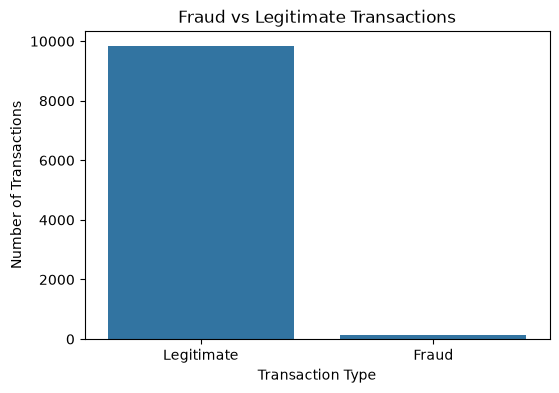

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x="is_fraud", data=df)

plt.title("Fraud vs Legitimate Transactions")

plt.xlabel("Transaction Type")

plt.ylabel("Number of Transactions")

plt.xticks([0,1],["Legitimate","Fraud"])

plt.show()

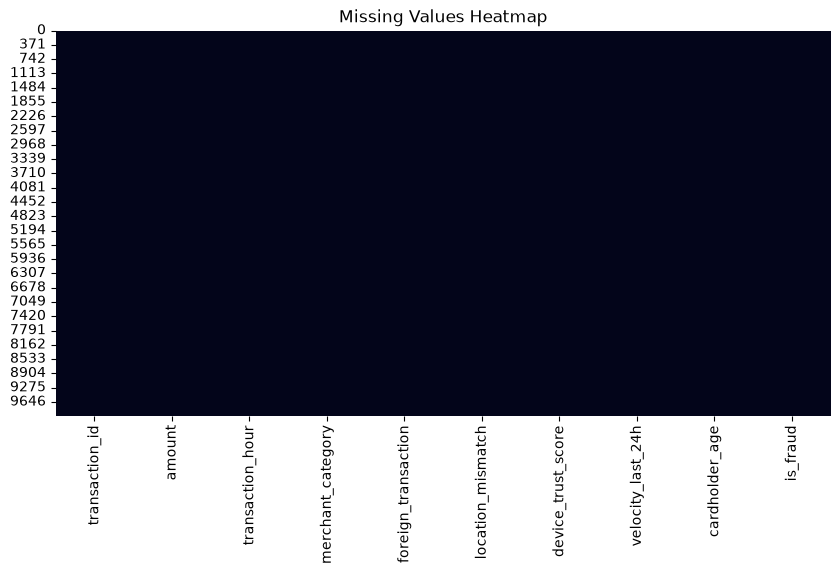

In [38]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

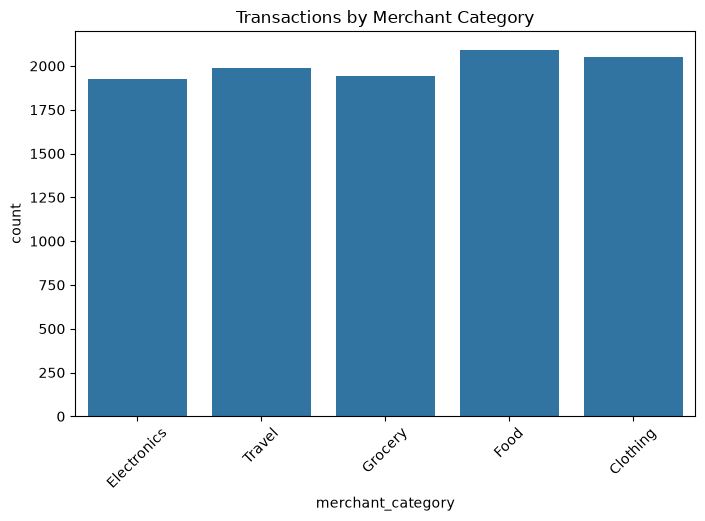

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(x="merchant_category", data=df)

plt.title("Transactions by Merchant Category")

plt.xticks(rotation=45)

plt.show()

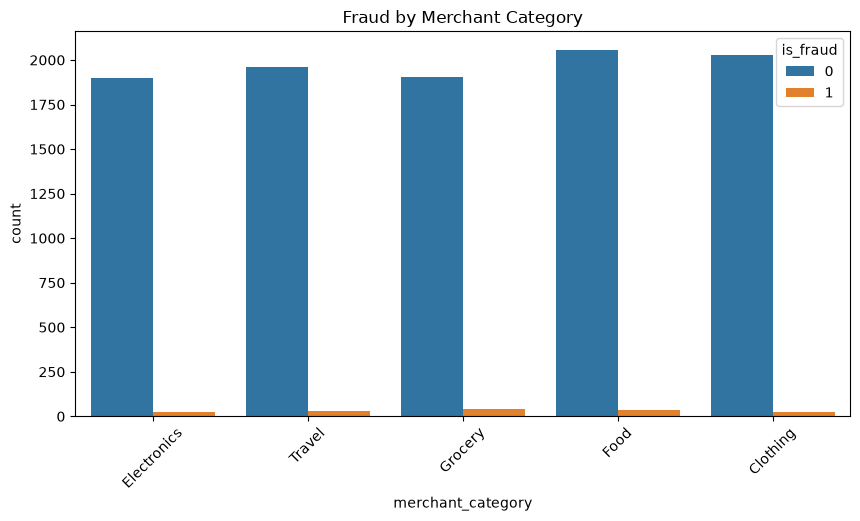

In [40]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="merchant_category",
    hue="is_fraud",
    data=df
)

plt.title("Fraud by Merchant Category")

plt.xticks(rotation=45)

plt.show()

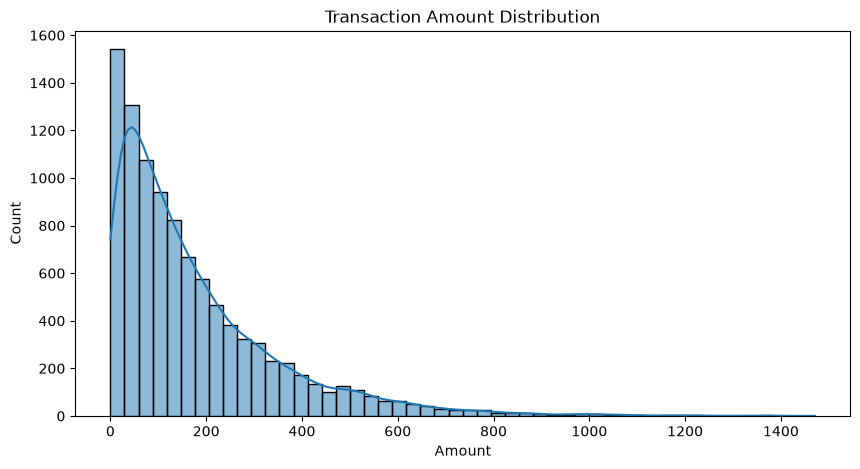

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(df["amount"], bins=50, kde=True)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.show()

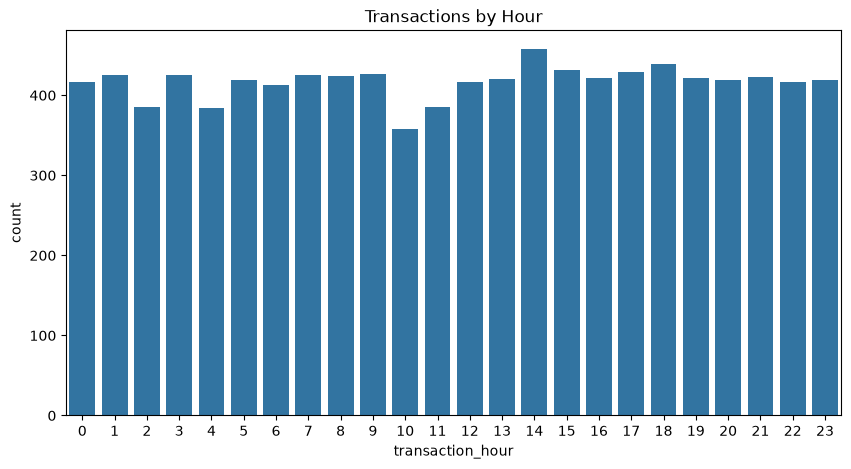

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(x="transaction_hour", data=df)

plt.title("Transactions by Hour")

plt.show()

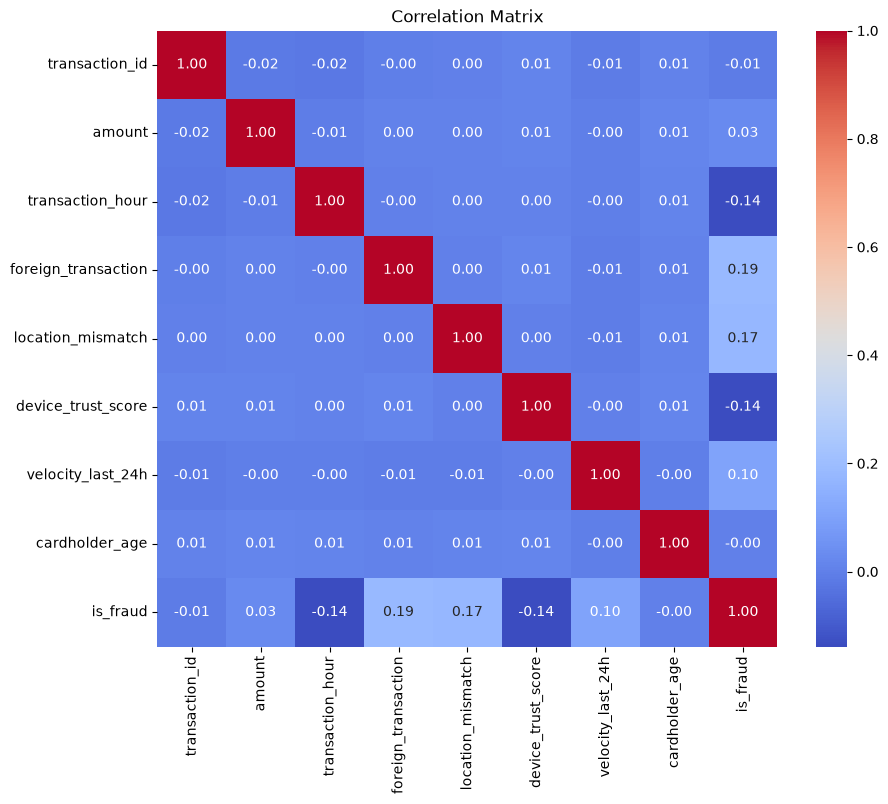

In [43]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## EDA Observations

##- Dataset contains 10,000 transactions.
##- No missing values.
##- No duplicate records.
##- Fraudulent transactions represent only 1.51% of the data.
##- The dataset is highly imbalanced.
##- Merchant categories include Food, Clothing, Grocery, Electronics, and Travel.
##- Transaction amount varies across a wide range.
##- Features such as foreign transactions, location mismatch, and device trust score may help identify fraudulent activity.


# Day 2: Data Preprocessing

In [44]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [46]:
import sklearn
import numpy
import scipy

print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)

scikit-learn: 1.9.1
numpy: 2.5.3
scipy: 1.18.1


In [47]:
# Features
X = df.drop("is_fraud", axis=1)

# Target
y = df["is_fraud"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 9)
Target Shape: (10000,)


# Day 3: Logistic Regression Model


In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

ImportError: DLL load failed while importing _pava_pybind: An Application Control policy has blocked this file.

In [ ]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

print(model)

In [ ]:
model.fit(X_train, y_train)

print("Model trained successfully!")